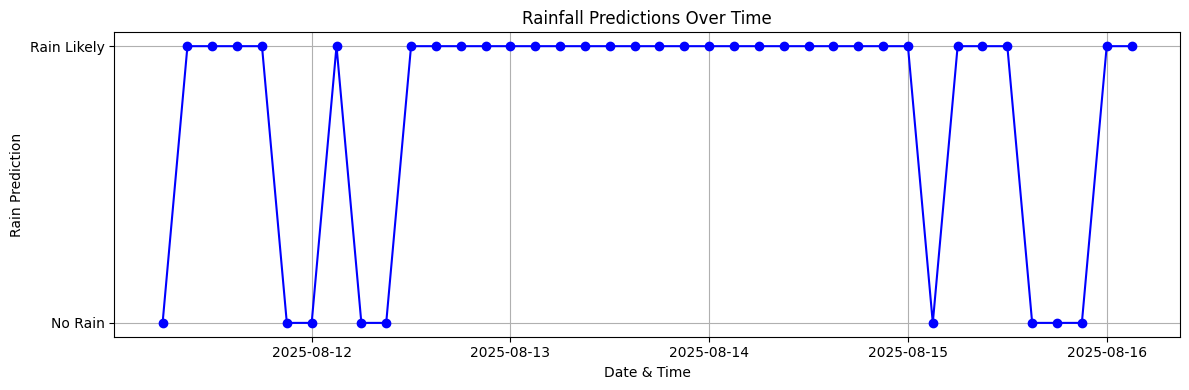

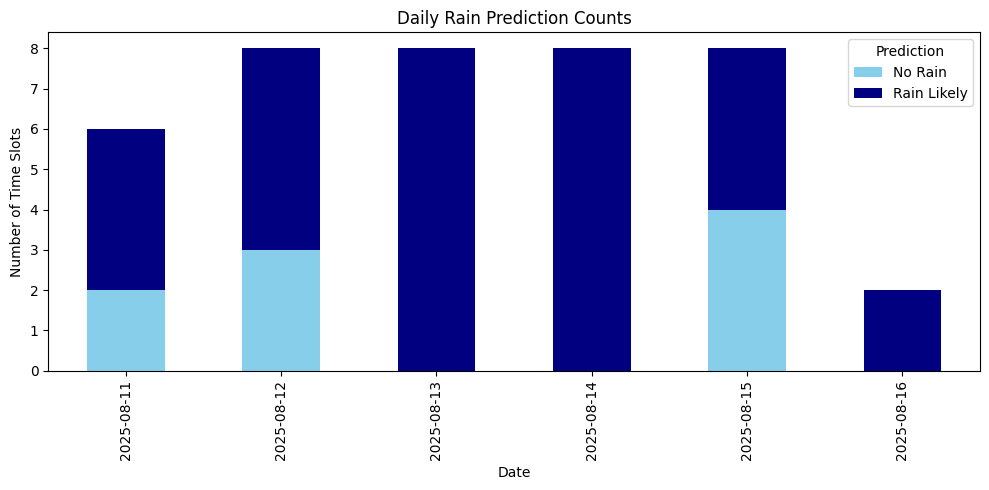

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("rainfall_predictions.csv")  # change filename to your actual file
df['datetime'] = pd.to_datetime(df['datetime'])

# Convert categorical to numeric
df['rain_flag'] = df['rain_prediction'].apply(lambda x: 1 if x.strip().lower() == "rain likely" else 0)

# --- Chart 1: Timeline plot ---
plt.figure(figsize=(12, 4))
plt.plot(df['datetime'], df['rain_flag'], marker='o', linestyle='-', color='blue')
plt.yticks([0, 1], ["No Rain", "Rain Likely"])
plt.xlabel("Date & Time")
plt.ylabel("Rain Prediction")
plt.title("Rainfall Predictions Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Chart 2: Daily stacked bar ---
df['date'] = df['datetime'].dt.date
daily_counts = df.groupby(['date', 'rain_prediction']).size().unstack(fill_value=0)
daily_counts.plot(kind='bar', stacked=True, figsize=(10, 5),
                  color={"No Rain": "skyblue", "Rain Likely": "navy"})
plt.title("Daily Rain Prediction Counts")
plt.xlabel("Date")
plt.ylabel("Number of Time Slots")
plt.legend(title="Prediction")
plt.tight_layout()
plt.show()
